In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
import warnings
warnings.simplefilter("ignore")

In [5]:
df = pd.read_csv('carros.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   kms     39 non-null     int64
 1   precio  39 non-null     int64
dtypes: int64(2)
memory usage: 756.0 bytes


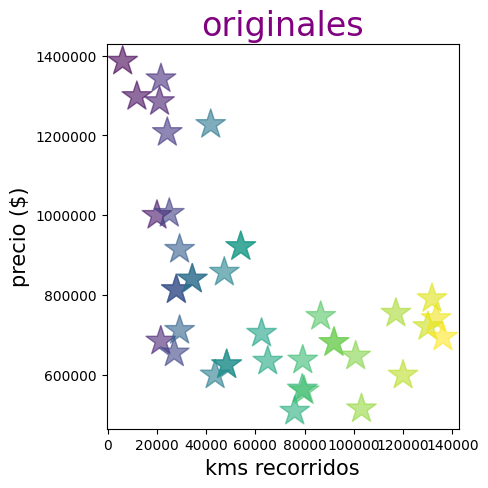

In [6]:
#cargar datos
#graficar crudos
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1,2,1)
ax.scatter(df["kms"], df["precio"], marker="*",
           s=500, c=range(df["kms"].size), alpha=0.6)

ax.set_title("originales", size=24, color="purple")
ax.set_ylabel("precio ($)", size=15)
ax.set_xlabel("kms recorridos", size=15)
ax.ticklabel_format(style="plain")

In [7]:
#escalamiento de datos
escala_kms= preprocessing.MinMaxScaler()
escala_precio = preprocessing.MinMaxScaler()
kms = escala_kms.fit_transform(df["precio"].values.reshape(-1,1))
precio = escala_precio.fit_transform(df["precio"].values.reshape(-1,1))

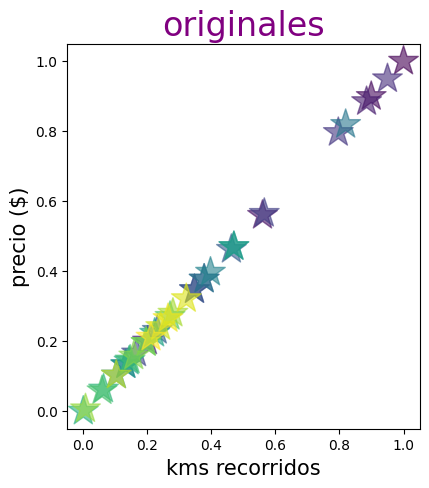

In [8]:
#escalamiento de datos
escala_kms= preprocessing.MinMaxScaler()
escala_precio = preprocessing.MinMaxScaler()
kms = escala_kms.fit_transform(df["precio"].values.reshape(-1,1))
precio = escala_precio.fit_transform(df["precio"].values.reshape(-1,1))

#graficar escalados:kms vs precio

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1,2,2)

ax.scatter(kms, precio, marker="*",
           s=500, c=range(kms.size), alpha=0.6)

ax.set_title("originales", size=24, color="purple")
ax.set_ylabel("precio ($)", size=15)
ax.set_xlabel("kms recorridos", size=15)
ax.ticklabel_format(style="plain")

plt.show()

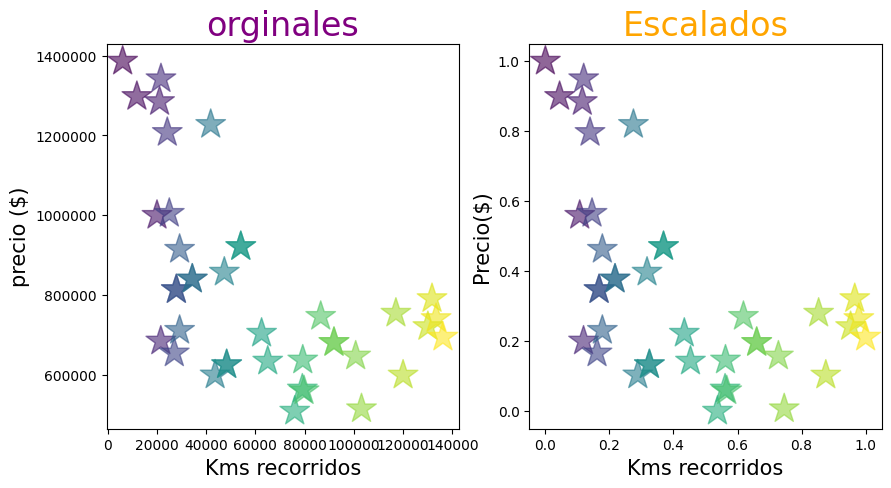

In [9]:
#cargar datos
#Graficar datos crudos: kms vs precio
fig = plt.figure(figsize=(10,5))

ax = fig.add_subplot(1,2,1)

ax.scatter(df['kms'],df["precio"], marker="*", s = 500, c = range(df['kms'].size), alpha=0.6)

ax.set_title("orginales", size = 24, color = "purple")
ax.set_ylabel("precio ($)", size = 15)
ax.set_xlabel("Kms recorridos", size = 15)
ax.ticklabel_format(style="plain")

#Escalamiento de los datos
escala_kms = preprocessing.MinMaxScaler()
escala_precio = preprocessing.MinMaxScaler()
kms = escala_kms.fit_transform(df['kms'].values.reshape(-1,1))
precio = escala_precio.fit_transform(df['precio'].values.reshape(-1,1))

#graficar datos escalados kms vs precio

ax = fig.add_subplot(1,2,2)
ax.scatter(kms,precio,marker="*", s=500, c=range(kms.size), alpha=0.6)

ax.set_title("Escalados", size = 24, color= "orange")
ax.set_ylabel("Precio($)", size = 15)
ax.set_xlabel("Kms recorridos", size = 15)
ax.ticklabel_format(style="plain")
plt.show()

In [10]:
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(kms, precio)

kms_instancia = escala_kms.transform([[2000]])
precio_instancia = knn.predict(kms_instancia)
escala_precio.inverse_transform(precio_instancia)

array([[1227846.]])

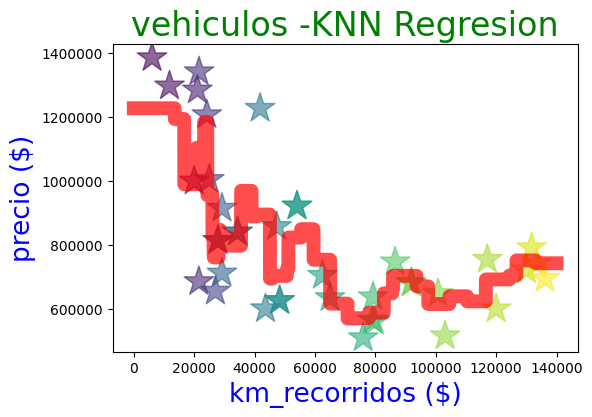

In [13]:
#carros de 0 a 140 mil km sus precios
#multiples

knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(kms,precio)
kms_instancias = escala_kms.transform(np.arange(140000).reshape(-1,1))
precio_instancias = knn.predict(kms_instancias)
todas = escala_precio.inverse_transform(precio_instancias)
todas = todas.reshape(-1,1)

#graficar resultados de las multoples regresiones
fig = plt.figure(figsize=(6, 4))

plt.plot(np.arange(140000), todas.reshape(1, -1)[0],
         linewidth=10, color="red", alpha=0.7)

plt.scatter(df["kms"], df["precio"], marker="*",
            s=500, c=range(df["kms"].size), alpha=0.6)

plt.title("vehiculos -KNN Regresion", size=24, color="green")
plt.ylabel("precio ($)", size=19, color="blue")
plt.xlabel("km_recorridos ($)", size=19, color="blue")
plt.ticklabel_format(style="plain")
plt.show()

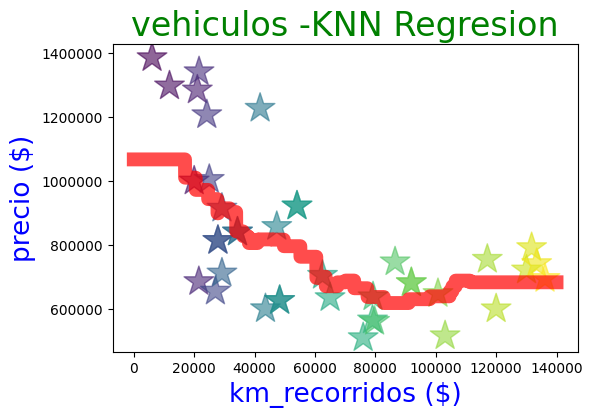

In [12]:
#carros de 0 a 140 mil km sus precios
#multiples

knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(kms,precio)
kms_instancias = escala_kms.transform(np.arange(140000).reshape(-1,1))
precio_instancias = knn.predict(kms_instancias)
todas = escala_precio.inverse_transform(precio_instancias)
todas = todas.reshape(-1,1)

#graficar resultados de las multoples regresiones
fig = plt.figure(figsize=(6, 4))

plt.plot(np.arange(140000), todas.reshape(1, -1)[0],
         linewidth=10, color="red", alpha=0.7)

plt.scatter(df["kms"], df["precio"], marker="*",
            s=500, c=range(df["kms"].size), alpha=0.6)

plt.title("vehiculos -KNN Regresion", size=24, color="green")
plt.ylabel("precio ($)", size=19, color="blue")
plt.xlabel("km_recorridos ($)", size=19, color="blue")
plt.ticklabel_format(style="plain")
plt.show()